In [2]:
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns

print("libraries loaded")

libraries loaded


In [3]:
# Check all 7 files are there
files = glob.glob('../data/raw/taxi/*.parquet')

print(f"Found {len(files)} files:")
for f in sorted(files):
    print(" ", f)

Found 8 files:
  ../data/raw/taxi\yellow_tripdata_2024-01.parquet
  ../data/raw/taxi\yellow_tripdata_2024-02.parquet
  ../data/raw/taxi\yellow_tripdata_2024-03.parquet
  ../data/raw/taxi\yellow_tripdata_2024-04.parquet
  ../data/raw/taxi\yellow_tripdata_2024-05.parquet
  ../data/raw/taxi\yellow_tripdata_2024-06.parquet
  ../data/raw/taxi\yellow_tripdata_2024-07.parquet
  ../data/raw/taxi\yellow_tripdata_2025-01.parquet


In [4]:
# Load all 6 training months (January to June) into one DataFrame
train_files = sorted(glob.glob('../data/raw/taxi/yellow_tripdata_2024-0[1-6].parquet'))

print("Loading these files as training data:")
for f in train_files:
    print(" ", os.path.basename(f))

df_train = pd.concat(
    [pd.read_parquet(f) for f in train_files],
    ignore_index=True
)

print(f"\nTraining data shape: {df_train.shape}")
print(f"Total rows: {len(df_train):,}")

Loading these files as training data:
  yellow_tripdata_2024-01.parquet
  yellow_tripdata_2024-02.parquet
  yellow_tripdata_2024-03.parquet
  yellow_tripdata_2024-04.parquet
  yellow_tripdata_2024-05.parquet
  yellow_tripdata_2024-06.parquet

Training data shape: (20332093, 19)
Total rows: 20,332,093


In [5]:
# Load July as the monitoring batch
df_july = pd.read_parquet('../data/raw/taxi/yellow_tripdata_2024-07.parquet')

print(f"July data shape: {df_july.shape}")
print(f"July rows: {len(df_july):,}")

July data shape: (3076903, 19)
July rows: 3,076,903


In [6]:
print("Training columns:", df_train.columns.tolist())
print("\nJuly columns:", df_july.columns.tolist())

# These should be identical
# If July has different columns that is already a schema drift event

Training columns: ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'Airport_fee']

July columns: ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'Airport_fee']


In [7]:
# Save combined training data as one file
# This is what the profiler and Isolation Forest will train on

os.makedirs('../data/raw', exist_ok=True)
df_train.to_parquet('../data/raw/taxi_train.parquet', index=False)
df_july.to_parquet('../data/raw/taxi_monitor.parquet', index=False)

print("Saved:")
print("  taxi_train.parquet  — Jan to Jun combined")
print("  taxi_monitor.parquet — July only")

Saved:
  taxi_train.parquet  — Jan to Jun combined
  taxi_monitor.parquet — July only


In [8]:
print("Shape:", df_train.shape)
print("\nColumn names:")
print(df_train.columns.tolist())

Shape: (20332093, 19)

Column names:
['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'Airport_fee']


In [ ]:
print(df_train.info())

<class 'pandas.DataFrame'>
RangeIndex: 20332093 entries, 0 to 20332092
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     str           
 7   PULocationID           int32         
 8   DOLocationID           int32         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee            float64 

In [10]:
null_rates = df_train.isnull().sum() / len(df_train) * 100
null_rates = null_rates.sort_values(ascending=False)

print("Null rate per column (%):\n")
print(null_rates.round(4))

Null rate per column (%):

store_and_fwd_flag       9.7186
RatecodeID               9.7186
passenger_count          9.7186
Airport_fee              9.7186
congestion_surcharge     9.7186
VendorID                 0.0000
tpep_pickup_datetime     0.0000
tpep_dropoff_datetime    0.0000
DOLocationID             0.0000
PULocationID             0.0000
trip_distance            0.0000
fare_amount              0.0000
payment_type             0.0000
extra                    0.0000
mta_tax                  0.0000
tolls_amount             0.0000
tip_amount               0.0000
total_amount             0.0000
improvement_surcharge    0.0000
dtype: float64


In [11]:
important_cols = [
    'fare_amount', 
    'trip_distance', 
    'passenger_count',
    'tip_amount',
    'total_amount'
]

# Only use columns that actually exist in the dataset
existing_cols = [c for c in important_cols if c in df_train.columns]

print(df_train[existing_cols].describe().round(2))

       fare_amount  trip_distance  passenger_count   tip_amount  total_amount
count  20332093.00    20332093.00      18356108.00  20332093.00   20332093.00
mean         18.89           4.70             1.33         3.27         27.44
std          77.29         359.25             0.83         4.01         78.55
min       -1285.40           0.00             0.00      -300.00      -1315.97
25%           9.30           1.02             1.00         0.00         15.64
50%          13.50           1.75             1.00         2.60         20.64
75%          21.90           3.30             1.00         4.16         29.85
max      334076.32      312722.30             9.00       999.99     334145.30


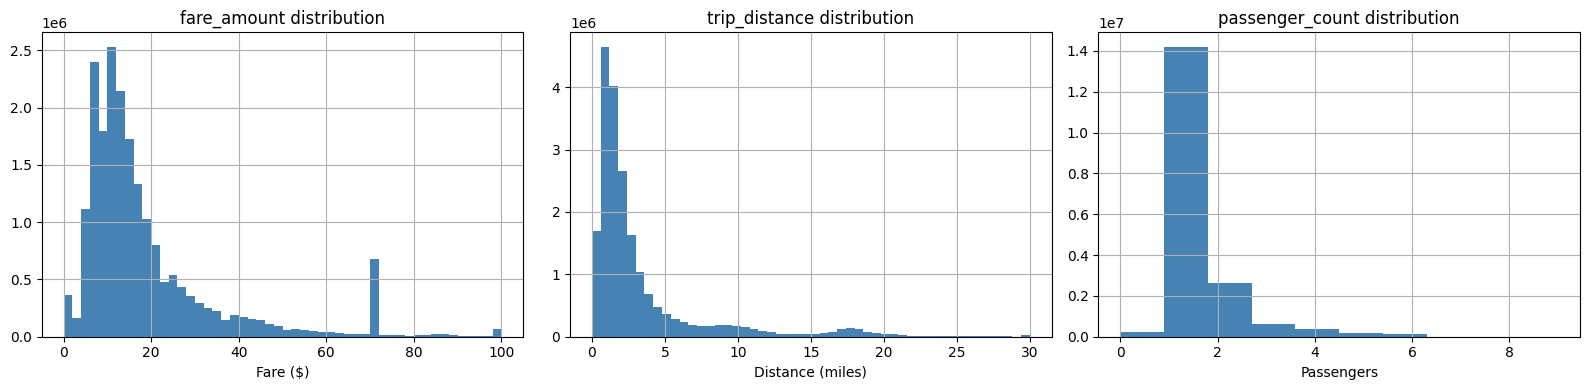

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df_train['fare_amount'].clip(0, 100).hist(
    bins=50, ax=axes[0], color='steelblue'
)
axes[0].set_title('fare_amount distribution')
axes[0].set_xlabel('Fare ($)')

df_train['trip_distance'].clip(0, 30).hist(
    bins=50, ax=axes[1], color='steelblue'
)
axes[1].set_title('trip_distance distribution')
axes[1].set_xlabel('Distance (miles)')

df_train['passenger_count'].hist(
    bins=10, ax=axes[2], color='steelblue'
)
axes[2].set_title('passenger_count distribution')
axes[2].set_xlabel('Passengers')

plt.tight_layout()
plt.show()

In [13]:
print("Negative fares:", (df_train['fare_amount'] < 0).sum())
print("Zero distance trips:", (df_train['trip_distance'] == 0).sum())
print("Passenger count = 0:", (df_train['passenger_count'] == 0).sum())
print("Extreme fares above $500:", (df_train['fare_amount'] > 500).sum())
print("Extreme distance above 100 miles:", (df_train['trip_distance'] > 100).sum())

Negative fares: 315747
Zero distance trips: 364322
Passenger count = 0: 221109
Extreme fares above $500: 244
Extreme distance above 100 miles: 725


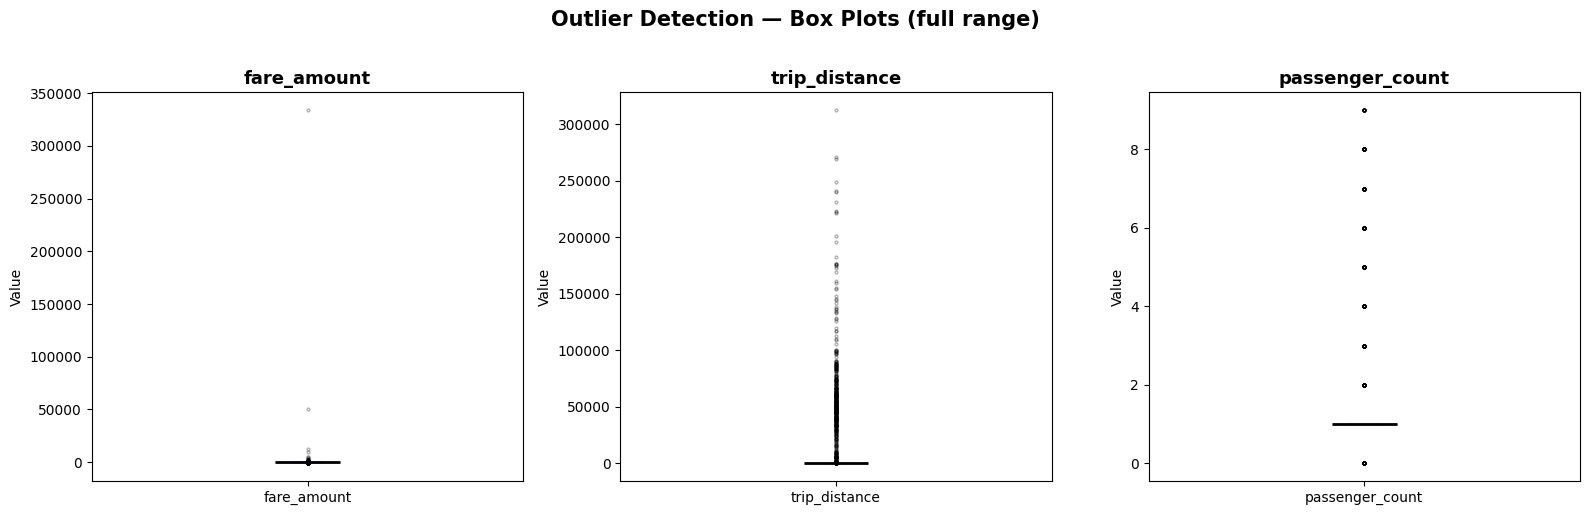

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

cols = ['fare_amount', 'trip_distance', 'passenger_count']
colors = ['#4C72B0', '#DD8452', '#55A868']

for ax, col, color in zip(axes, cols, colors):
    df_train[col].plot(
        kind='box',
        ax=ax,
        color=color,
        patch_artist=True,
        boxprops=dict(facecolor=color, alpha=0.4),
        medianprops=dict(color='black', linewidth=2),
        flierprops=dict(marker='o', markersize=2, alpha=0.3)
    )
    ax.set_title(f'{col}', fontsize=13, fontweight='bold')
    ax.set_ylabel('Value')

plt.suptitle('Outlier Detection — Box Plots (full range)', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [17]:
print("EXTREME OUTLIER COUNTS\n")
print("-" * 45)

# fare_amount
q99_fare = df_train['fare_amount'].quantile(0.99)
extreme_fare = (df_train['fare_amount'] > q99_fare).sum()
negative_fare = (df_train['fare_amount'] < 0).sum()
print(f"fare_amount above 99th percentile (${q99_fare:.2f}): {extreme_fare:,} rows")
print(f"fare_amount negative:                                  {negative_fare:,} rows")

print()

# trip_distance
q99_dist = df_train['trip_distance'].quantile(0.99)
extreme_dist = (df_train['trip_distance'] > q99_dist).sum()
zero_dist = (df_train['trip_distance'] == 0).sum()
print(f"trip_distance above 99th percentile ({q99_dist:.2f} mi): {extreme_dist:,} rows")
print(f"trip_distance = 0:                                        {zero_dist:,} rows")

print()

# passenger_count
extreme_pass = (df_train['passenger_count'] > 6).sum()
zero_pass = (df_train['passenger_count'] == 0).sum()
print(f"passenger_count above 6:  {extreme_pass:,} rows")
print(f"passenger_count = 0:      {zero_pass:,} rows")

print()
print("-" * 45)

EXTREME OUTLIER COUNTS

---------------------------------------------
fare_amount above 99th percentile ($76.90): 203,090 rows
fare_amount negative:                                  315,747 rows

trip_distance above 99th percentile (19.88 mi): 202,847 rows
trip_distance = 0:                                        364,322 rows

passenger_count above 6:  164 rows
passenger_count = 0:      221,109 rows

---------------------------------------------


In [18]:
print("Training columns:", df_train.columns.tolist())
print("\nJuly columns:", df_july.columns.tolist())

# Check if any column is different
train_cols = set(df_train.columns)
july_cols = set(df_july.columns)

if train_cols == july_cols:
    print("\nStructure matches — good to go")
else:
    print("\nDifferences found:")
    print("In training but not July:", train_cols - july_cols)
    print("In July but not training:", july_cols - train_cols)

Training columns: ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'Airport_fee']

July columns: ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'Airport_fee']

Structure matches — good to go


In [19]:
print(f"Training rows: {len(df_train):,}")
print(f"July rows:     {len(df_july):,}")
print(f"July is roughly {len(df_july)/len(df_train)*100:.1f}% the size of training data")

Training rows: 20,332,093
July rows:     3,076,903
July is roughly 15.1% the size of training data


#Summary

# Data Shape: (20332093, 19) 
"""There are a lot of null values around ~200k in these coulmns [
store_and_fwd_flag, 
RatecodeID,
passenger_count,
Airport_fee,
congestion_surcharge 
"""
#--------------------------------------
""" 
most important coulmns :
[   'fare_amount', 
    'trip_distance', 
    'passenger_count',
    'tip_amount',
    'total_amount'  ]
    
"""
#----------------------------------
#Already existing weird values
"""
Negative fares: 315747
Zero distance trips: 364322
Passenger count = 0: 221109
Extreme fares above $500: 244 
Extreme distance above 100 miles: 725 
"""
#-----------------------------------
"""
What the detector should catch in July
- Any fare above $$76.90 >> 99% quantile 
- Any distance above 19.88 mi miles >> 99% quantile 
- Any passenger count above 6 
- Any Null rates spikes 
- Any Data drifts 
- Any Data 
""" 
     